In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# Load the dataset
df = pd.read_csv('bitcoin_history.csv')

In [25]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,"Feb 20, 2025","96,628.40","98,722.29","96,481.41","98,347.95","98,347.95","31,327,236,096"
1,"Feb 19, 2025","95,532.53","96,855.59","95,011.97","96,635.61","96,635.61","28,990,872,862"
2,"Feb 18, 2025","95,773.81","96,695.38","93,388.84","95,539.55","95,539.55","37,325,720,482"
3,"Feb 17, 2025","96,179.01","97,032.23","95,243.55","95,773.38","95,773.38","27,336,550,690"
4,"Feb 16, 2025","97,580.49","97,725.59","96,060.98","96,175.03","96,175.03","16,536,755,396"


In [26]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
3805,"Sep 21, 2014",408.08,412.43,393.18,398.82,398.82,"26,580,100"
3806,"Sep 20, 2014",394.67,423.30,389.88,408.90,408.90,"36,863,600"
3807,"Sep 19, 2014",424.10,427.83,384.53,394.80,394.80,"37,919,700"
3808,"Sep 18, 2014",456.86,456.86,413.10,424.44,424.44,"34,483,200"
3809,"Sep 17, 2014",465.86,468.17,452.42,457.33,457.33,"21,056,800"


In [27]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       3810 non-null   object
 1   Open       3810 non-null   object
 2   High       3810 non-null   object
 3   Low        3810 non-null   object
 4   Close      3810 non-null   object
 5   Adj Close  3810 non-null   object
 6   Volume     3810 non-null   object
dtypes: object(7)
memory usage: 208.5+ KB


In [29]:
# Data Cleaning
df['Date'] = pd.to_datetime(df['Date'])
numeric_columns = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
for col in numeric_columns:
    df[col] = df[col].str.replace(',', '').astype(float)

# Set style
sns.set(style='darkgrid')

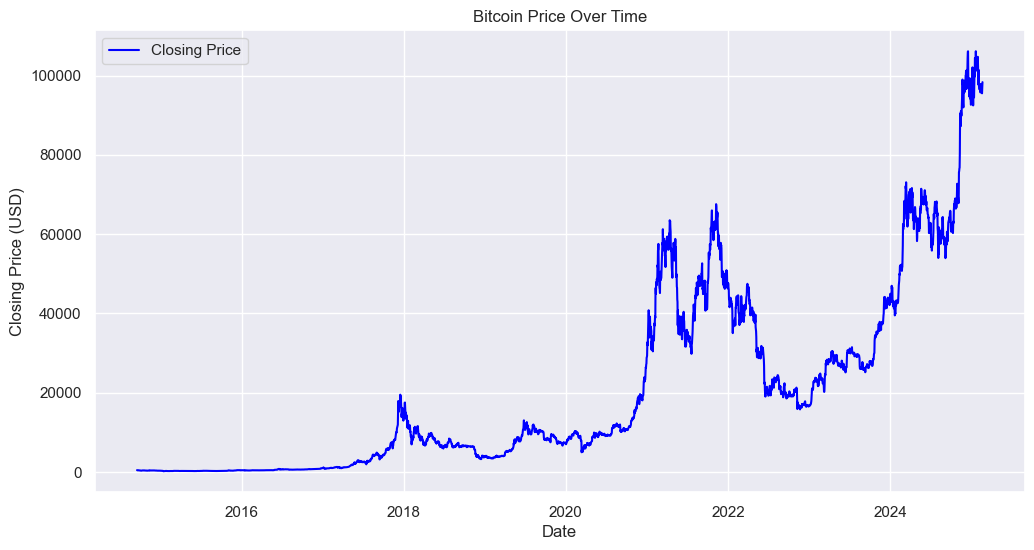

In [30]:
# Line Plot: Bitcoin Price Over Time
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Closing Price', color='blue')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.title('Bitcoin Price Over Time')
plt.legend()
plt.show()

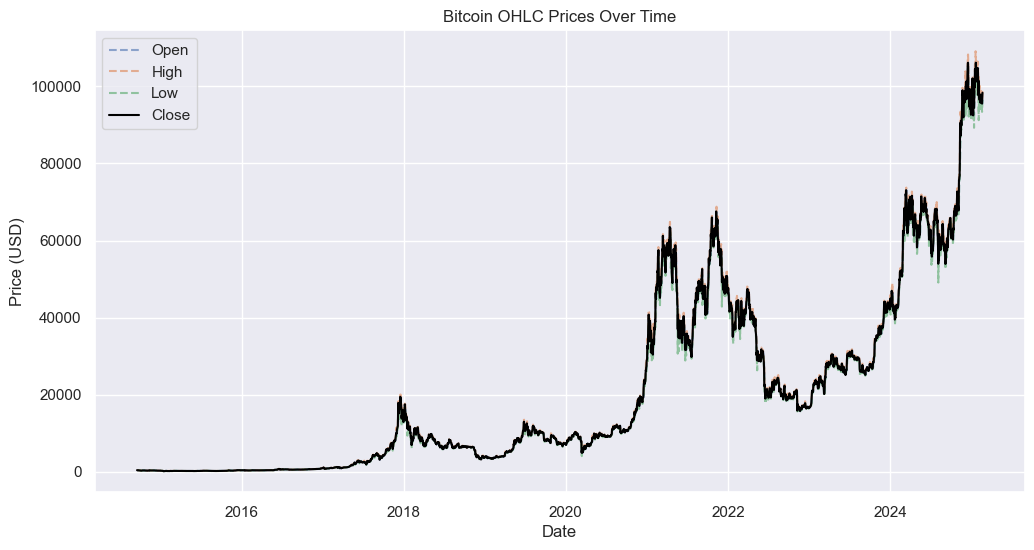

In [31]:
# Candlestick Chart using OHLC (Matplotlib)
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(df['Date'], df['Open'], label='Open', linestyle='dashed', alpha=0.6)
ax.plot(df['Date'], df['High'], label='High', linestyle='dashed', alpha=0.6)
ax.plot(df['Date'], df['Low'], label='Low', linestyle='dashed', alpha=0.6)
ax.plot(df['Date'], df['Close'], label='Close', color='black')
ax.set_title('Bitcoin OHLC Prices Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.show()

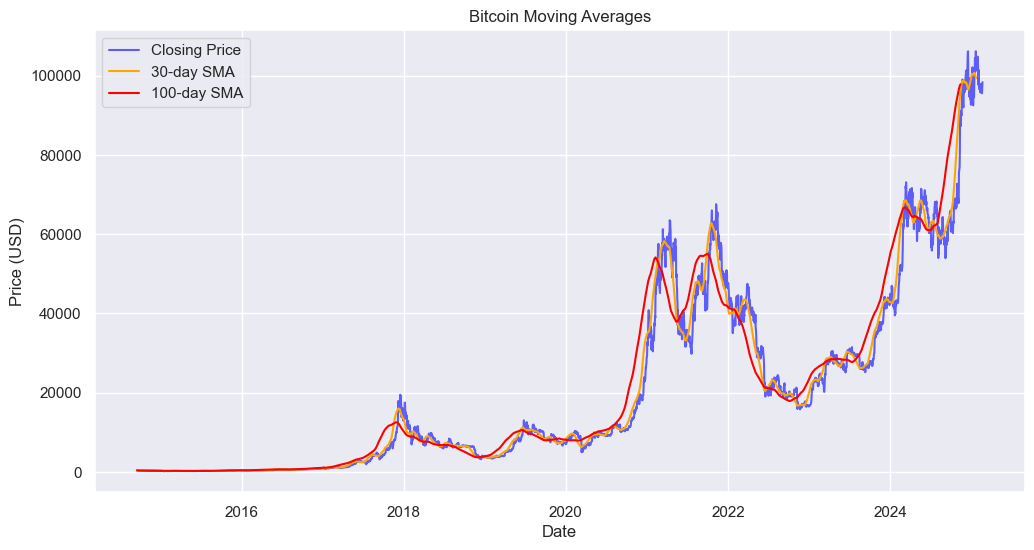

In [32]:
# Moving Averages
df['SMA_30'] = df['Close'].rolling(window=30).mean()
df['SMA_100'] = df['Close'].rolling(window=100).mean()
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Closing Price', color='blue', alpha=0.6)
plt.plot(df['Date'], df['SMA_30'], label='30-day SMA', color='orange')
plt.plot(df['Date'], df['SMA_100'], label='100-day SMA', color='red')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('Bitcoin Moving Averages')
plt.legend()
plt.show()

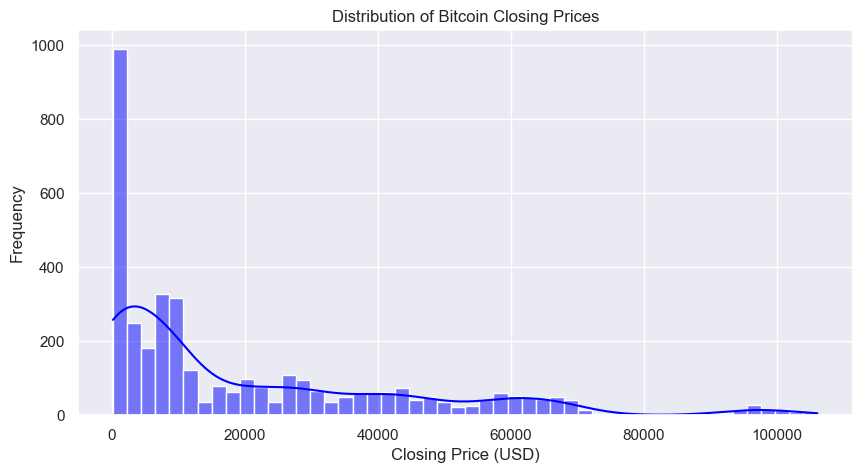

In [33]:
# Histogram: Distribution of Closing Prices
plt.figure(figsize=(10,5))
sns.histplot(df['Close'], bins=50, kde=True, color='blue')
plt.xlabel('Closing Price (USD)')
plt.ylabel('Frequency')
plt.title('Distribution of Bitcoin Closing Prices')
plt.show()

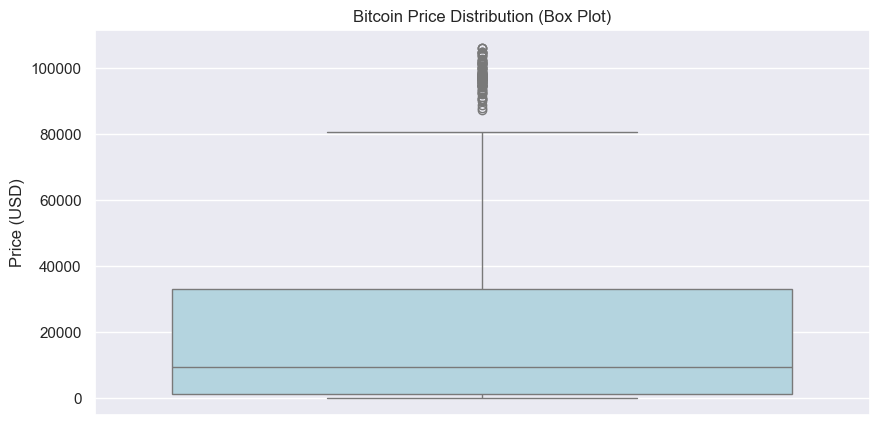

In [34]:
# Box Plot: Price Distribution to Identify Outliers
plt.figure(figsize=(10,5))
sns.boxplot(y=df['Close'], color='lightblue')
plt.ylabel('Price (USD)')
plt.title('Bitcoin Price Distribution (Box Plot)')
plt.show()

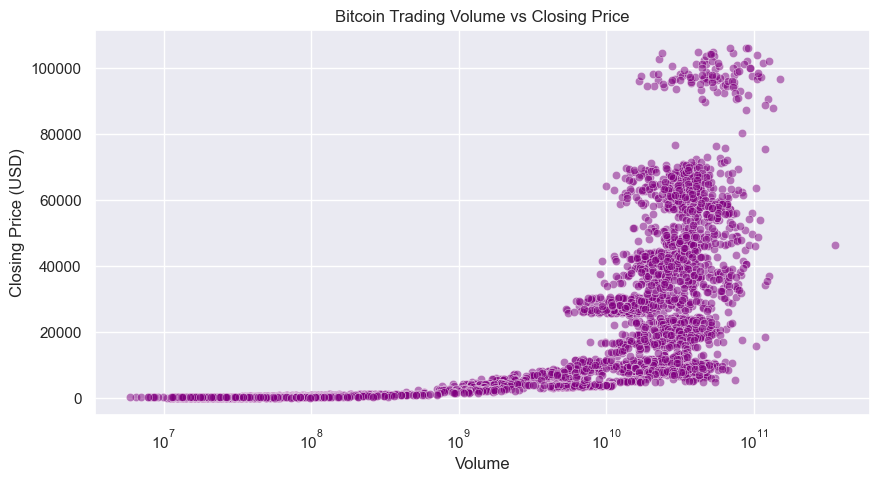

In [35]:
# Scatter Plot: Volume vs. Closing Price
plt.figure(figsize=(10,5))
sns.scatterplot(x=df['Volume'], y=df['Close'], alpha=0.5, color='purple')
plt.xlabel('Volume')
plt.ylabel('Closing Price (USD)')
plt.title('Bitcoin Trading Volume vs Closing Price')
plt.xscale('log')  # Log scale to handle large volume values
plt.show()

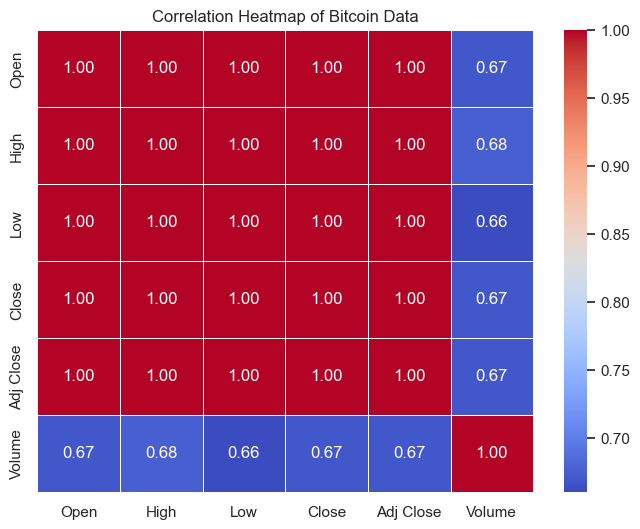

In [36]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
corr = df[numeric_columns].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Bitcoin Data')
plt.show()

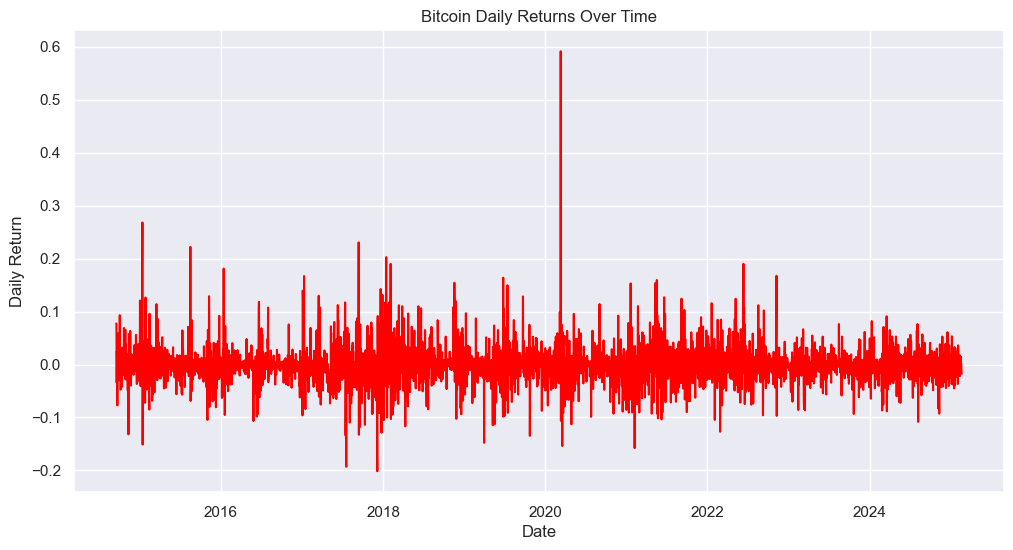

In [37]:
# Volatility Analysis (Daily Returns)
df['Daily Return'] = df['Close'].pct_change()
plt.figure(figsize=(12,6))
sns.lineplot(x=df['Date'], y=df['Daily Return'], color='red')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.title('Bitcoin Daily Returns Over Time')
plt.show()

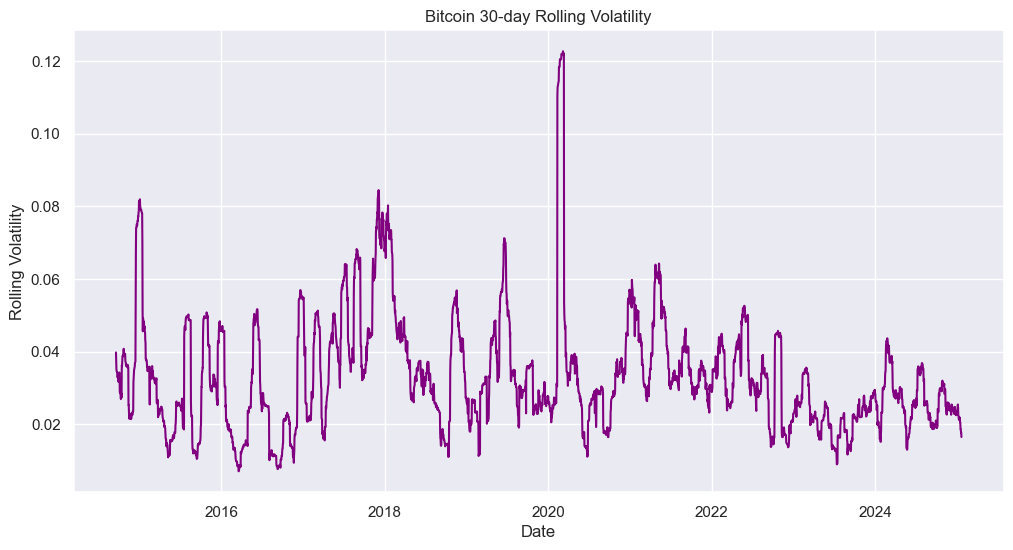

In [38]:
# Rolling Volatility (30-day Standard Deviation)
df['Rolling Volatility'] = df['Daily Return'].rolling(window=30).std()
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Rolling Volatility'], color='purple')
plt.xlabel('Date')
plt.ylabel('Rolling Volatility')
plt.title('Bitcoin 30-day Rolling Volatility')
plt.show()

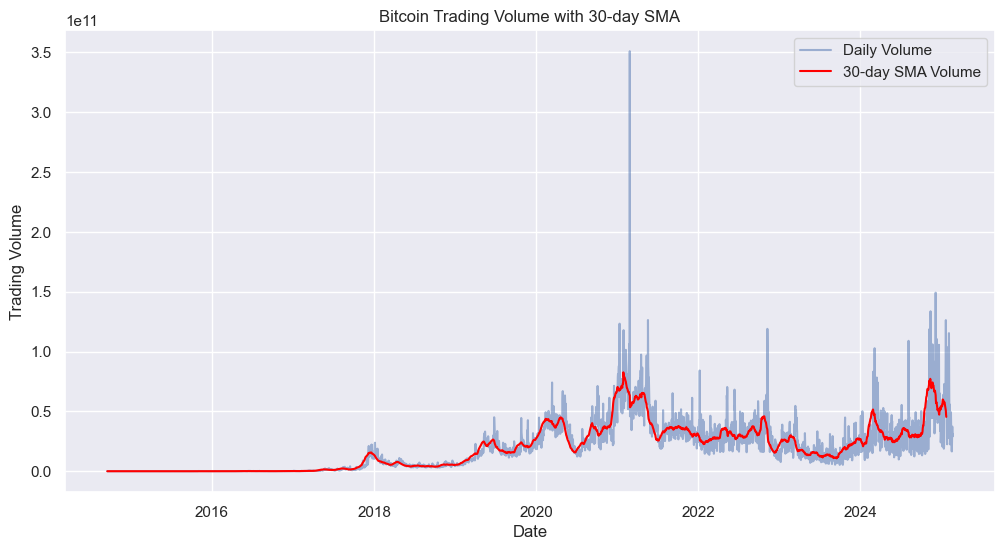

In [39]:
# Volume Moving Average
df['Volume_SMA_30'] = df['Volume'].rolling(window=30).mean()
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Volume'], label='Daily Volume', alpha=0.5)
plt.plot(df['Date'], df['Volume_SMA_30'], label='30-day SMA Volume', color='red')
plt.xlabel('Date')
plt.ylabel('Trading Volume')
plt.title('Bitcoin Trading Volume with 30-day SMA')
plt.legend()
plt.show()

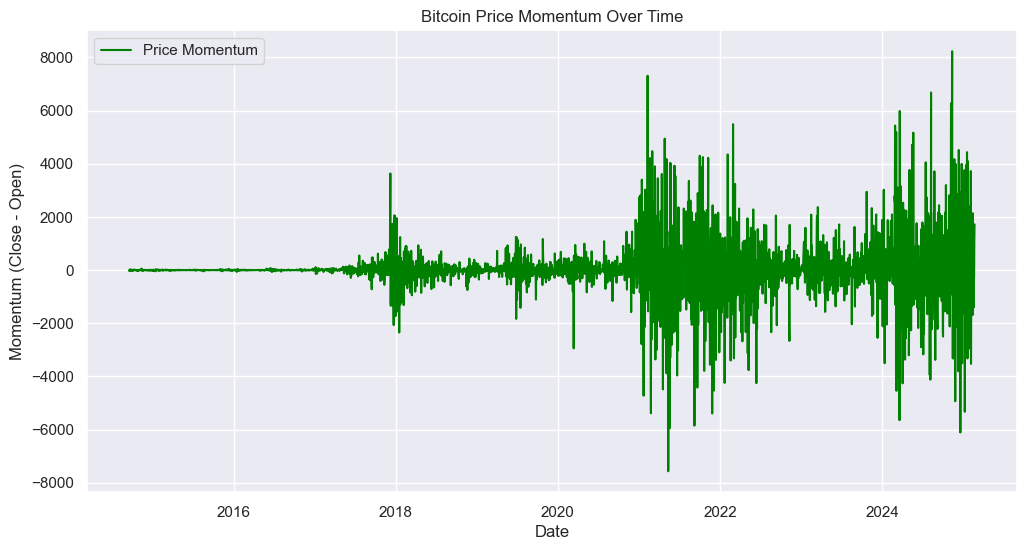

In [40]:
# Price Momentum Indicator (Difference between Close and Open Prices)
df['Momentum'] = df['Close'] - df['Open']
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Momentum'], label='Price Momentum', color='green')
plt.xlabel('Date')
plt.ylabel('Momentum (Close - Open)')
plt.title('Bitcoin Price Momentum Over Time')
plt.legend()
plt.show()

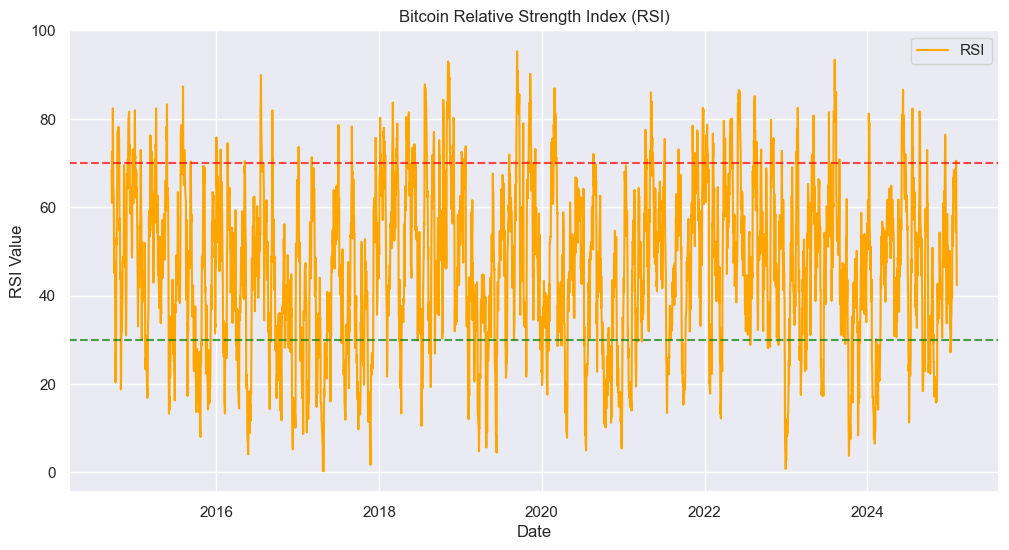

In [41]:
# Relative Strength Index (RSI) Calculation
window_length = 14
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=window_length).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=window_length).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['RSI'], label='RSI', color='orange')
plt.axhline(70, linestyle='--', color='red', alpha=0.7)
plt.axhline(30, linestyle='--', color='green', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('RSI Value')
plt.title('Bitcoin Relative Strength Index (RSI)')
plt.legend()
plt.show()

In [43]:
df.to_csv('ds.csv', index=False)